In [1]:
from rdkit.Chem import Descriptors, Crippen, QED
from rdkit.Chem.Draw import IPythonConsole
from collections import defaultdict
from rdkit import Chem
from rdkit.Chem import Draw
from collections import Counter
from tqdm import tqdm
import pandas as pd
import numpy as np
import random
import os

In [2]:
root = "/home/acomajuncosa/Documents_GPU/mtb-targeted-protein-degradation"
PATH_TO_SELECTED_COMPOUNDS = os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", "selected_compounds")

In [3]:
def get_splits(path):
    splits = os.listdir(path)
    return [i.replace(".csv", "") for i in sorted(splits)]

def get_pockets():
    df = pd.read_csv("/home/acomajuncosa/Documents_GPU/mtb-targeted-protein-degradation/processed/pocket_detection_data.csv")
    pockets = [f"{i.replace('.pdb', '')}_pocket_{j}" for i, j in zip(df['File name'], df['Pocket number'])]
    return sorted(pockets)

def smiles_grid(smiles, per_row=4, size=(200, 200)):
    mols = [Chem.MolFromSmiles(s) for s in smiles]
    return Draw.MolsToGridImage(mols, molsPerRow=per_row, subImgSize=size, maxMols=10_000)

# Get splits (994)
SPLITS = get_splits(os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", 'A_proteins'))

# Get pockets (276)
POCKETS = get_pockets()

In [4]:
df = []
for split in SPLITS:
    df_ = pd.read_csv(os.path.join(os.path.join(PATH_TO_SELECTED_COMPOUNDS, f"{split}.csv")))
    df.append(df_)
df = pd.concat(df, ignore_index=True)
rng = np.random.default_rng(42)
df["rd"] = rng.random(len(df))
CUSTOM_ORDER = ['A_pockets', 'A_proteins', 'B_proteins', 'B_pockets']
df["label"] = pd.Categorical(df["label"], categories=CUSTOM_ORDER, ordered=True)
df = df.sort_values(["label", "rd"], ascending=[True, True], kind="stable").reset_index(drop=True)
df[['smiles']].to_csv(os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", "selected_compounds_smiles.csv"), index=False)  # to run ersilia models

In [5]:
Counter(df['index'] == df['index.1'])

Counter({True: 1033664})

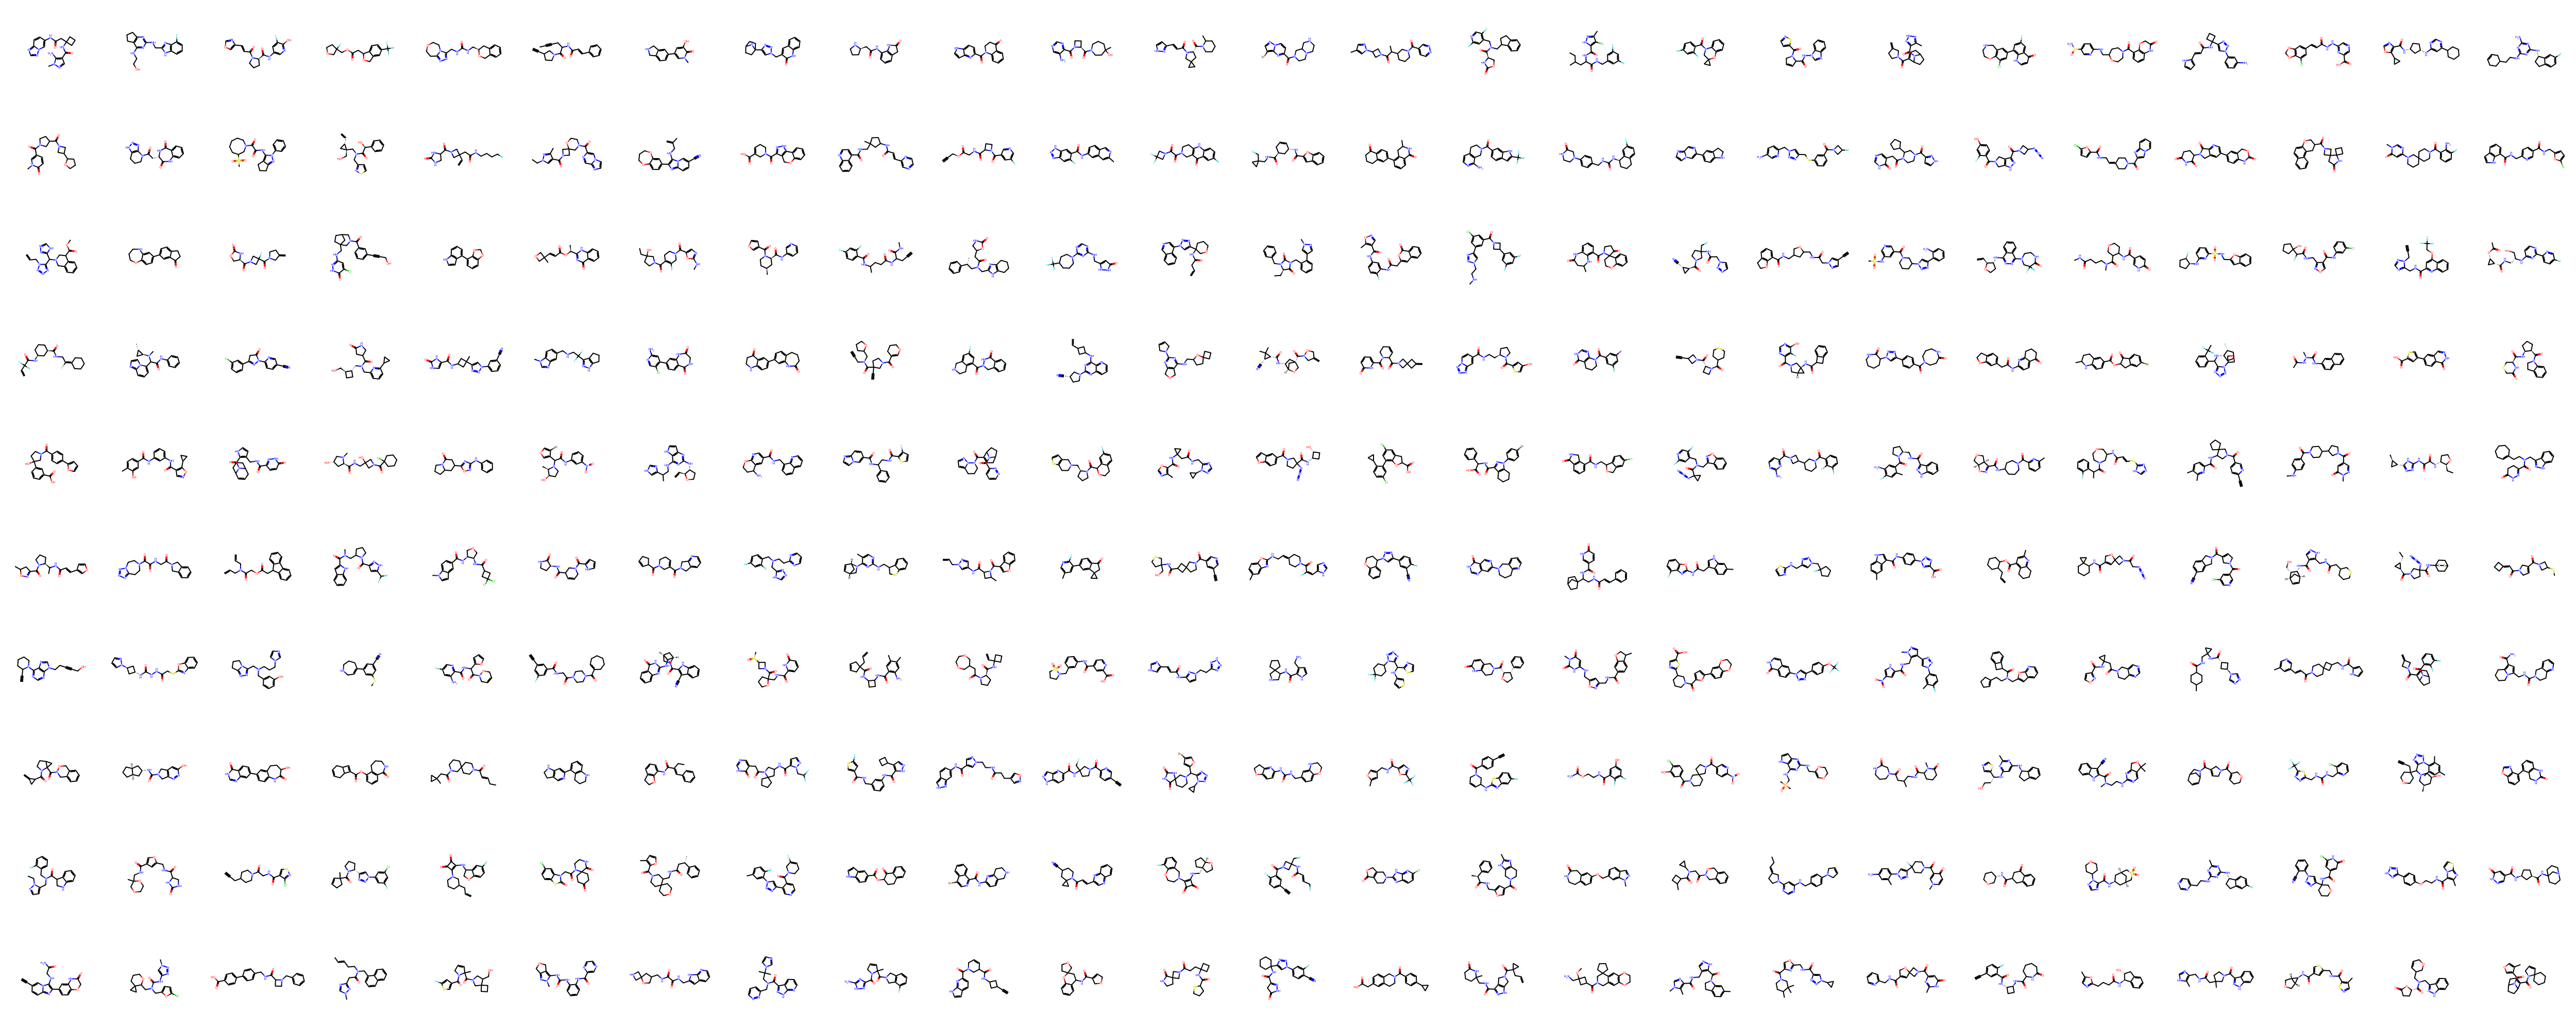

In [6]:
random.seed(42)
rd_cpds = random.sample(df['smiles'].tolist(), 10 * 25)
rd_cpds = [i.split()[0] for i in rd_cpds]
smiles_grid(rd_cpds, per_row=25)

In [7]:
mols = [Chem.MolFromSmiles(smi) for smi in tqdm(df['smiles'])]

100%|██████████| 1033664/1033664 [01:25<00:00, 12122.69it/s]


In [8]:
df['MW'] = [Descriptors.MolWt(m) for m in tqdm(mols)]

100%|██████████| 1033664/1033664 [00:01<00:00, 764306.49it/s]


In [9]:
df['logp'] = [Crippen.MolLogP(m) for m in tqdm(mols)]

100%|██████████| 1033664/1033664 [02:22<00:00, 7236.54it/s]


In [10]:
df['QED'] = [QED.qed(m) for m in tqdm(mols)]

100%|██████████| 1033664/1033664 [12:30<00:00, 1377.31it/s]


In [30]:
eos12x7 = pd.read_csv(os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", "ersilia", "eos12x7.csv"))[["input", "nsps_score"]]

In [31]:
assert (eos12x7['input'] == df['smiles']).all

In [42]:
results = pd.concat([df, eos12x7], axis=1)
assert (results['input'] == results['smiles']).all
del results['index.1'], results['input']

In [51]:
results = results[(results['MW'] > 250) & (results['MW'] < 450) & 
                  (results['logp'] > -1) & (results['logp'] < 5) & 
                  (results['QED'] > 0.4) & 
                  (results['nsps_score'] > 10) & (results['nsps_score'] < 40)].reset_index(drop=True)

In [54]:
results

,split,index,n_targets,label,smiles,id,rd,MW,logp,QED,nsps_score
0,Enamine_REAL_LeadLike_342,6157521,273.0,A_pockets,O=C1C=CC=C(C(=O)NCC2=CCCN(C(=O)C3=NNC(=O)C3)C2)N1,m_275592____25037044____13187268____15858220,0.000004,343.343,-0.86070,0.615409,16.800000
1,Enamine_REAL_LeadLike_402,204310,272.0,A_pockets,[N-]=[N+]=NC1CCN(C(=O)[C@@H]2CCCN2C(=O)C2=CC3=...,m_274552____23414938____15962996____15976146,0.000007,352.398,2.68370,0.520919,22.615385
2,Enamine_REAL_NaturalProducts_036,9440957,272.0,A_pockets,O=C1C=CC([C@@H]2OCC[C@H]2NC(=O)[C@@H]2OCCC[C@H...,s_11____22175474____14417596,0.000012,368.433,2.28390,0.867683,28.000000
3,Enamine_REAL_LeadLike_570,9708359,274.0,A_pockets,NC1=CC(N2C=C(C3=C(C(=O)N4CNC(=O)C4)NN=C3)N=N2)...,m_279130____28580338____28139450____28610894,0.000020,374.311,0.04730,0.554523,13.851852
4,Enamine_REAL_LeadLike_130,393311,275.0,A_pockets,O=C1NC[C@H]2CN(C(=O)OC3=CC=CC4=CC=CC=C43)C[C@@...,s_282070____22247592____23868088,0.000026,296.326,2.01640,0.875571,23.454545
...,...,...,...,...,...,...,...,...,...,...,...
964988,Enamine_REAL_LeadLike_220,3741441,50.0,B_pockets,O=C(O)C1=CC=CC2=C(NCC3=CC=CC4=NSN=C34)C=CC=C12,s_274370____17665354____25890736,0.999980,335.388,4.15480,0.585701,11.000000
964989,Enamine_REAL_LeadLike_390,6011251,50.0,B_pockets,NC1=CC(C2=C(Cl)C3=C(C=C2)OCCC3)=CC(C(=O)N2CCOC...,s_271570____16463822____30510106,0.999982,372.852,3.38660,0.820555,16.730769
964990,Enamine_REAL_LeadLike_262,1997779,50.0,B_pockets,CC1=CNC(CN(CC2=CCCCC2)C(=O)CC2CNC(=O)C2)=N1,m_282151____27574440____25184554____25233244,0.999983,330.432,2.07332,0.783935,20.625000
964991,Enamine_REAL_LeadLike_527,8889,50.0,B_pockets,NC1=CN=CN=C1C(=O)NC(C(=O)NOCC1=CC=CC=C1)C1=CC=CS1,m_274552____23522306____25001182____25038672,0.999984,383.433,1.83940,0.535733,11.555556


In [55]:
results.to_csv(os.path.join(root, "processed", "unidock_REAL_docking", "inference_10B", "filtered_compounds.csv"), index=False)